### Carrega o dataset MNIST usando o Keras

In [1]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

### Normalizacao das imagens (intervalo [0, 1])

In [2]:
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

### One hot enconding nos rótulos

In [3]:
# Sobre o nível para a raiz do projeto, para conseguir importar funcoes do /mlp
import sys
sys.path.append('..')

from mlp.losses import one_hot

y_train = one_hot(y_train)
y_test = one_hot(y_test)

### Treino e Plots

In [11]:
from mlp.network import MLP
from mlp.optimizers import SGD

configs = [
    {"lr": 0.01, "label": "lr=0.01"},
    {"lr": 0.1,  "label": "lr=0.1"},
]

def train_mlp(lr):
    mlp = MLP([784, 128, 64, 10])
    optimizer = SGD(lr=lr)
    mlp.fit(X_train, y_train, optimizer, epochs=10, batch_size=64)
    print(f"Acurácia no teste: {mlp.accuracy(X_test, y_test):.4f}")
    return mlp

mlp_1 = train_mlp(configs[0]['lr'])
mlp_2 = train_mlp(configs[1]['lr'])


Epoch 1/10 - Loss: 2.3041 - Acc: 0.1124
Epoch 2/10 - Loss: 2.3025 - Acc: 0.1124
Epoch 3/10 - Loss: 2.2956 - Acc: 0.2643
Epoch 4/10 - Loss: 2.1288 - Acc: 0.4176
Epoch 5/10 - Loss: 1.1295 - Acc: 0.7530
Epoch 6/10 - Loss: 0.6996 - Acc: 0.8009
Epoch 7/10 - Loss: 0.6169 - Acc: 0.8267
Epoch 8/10 - Loss: 0.5630 - Acc: 0.8430
Epoch 9/10 - Loss: 0.5034 - Acc: 0.8662
Epoch 10/10 - Loss: 0.4378 - Acc: 0.8843
Acurácia no teste: 0.8832
Epoch 1/10 - Loss: 1.3148 - Acc: 0.8759
Epoch 2/10 - Loss: 0.2994 - Acc: 0.9355
Epoch 3/10 - Loss: 0.1795 - Acc: 0.9571
Epoch 4/10 - Loss: 0.1324 - Acc: 0.9708
Epoch 5/10 - Loss: 0.1040 - Acc: 0.9753
Epoch 6/10 - Loss: 0.0859 - Acc: 0.9746
Epoch 7/10 - Loss: 0.0718 - Acc: 0.9578
Epoch 8/10 - Loss: 0.0606 - Acc: 0.9863
Epoch 9/10 - Loss: 0.0531 - Acc: 0.9889
Epoch 10/10 - Loss: 0.0442 - Acc: 0.9882
Acurácia no teste: 0.9744


### Plots 

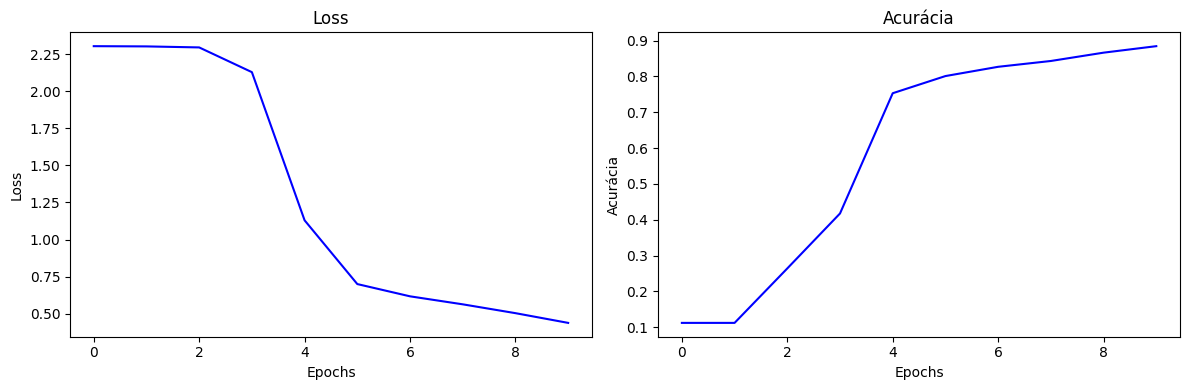

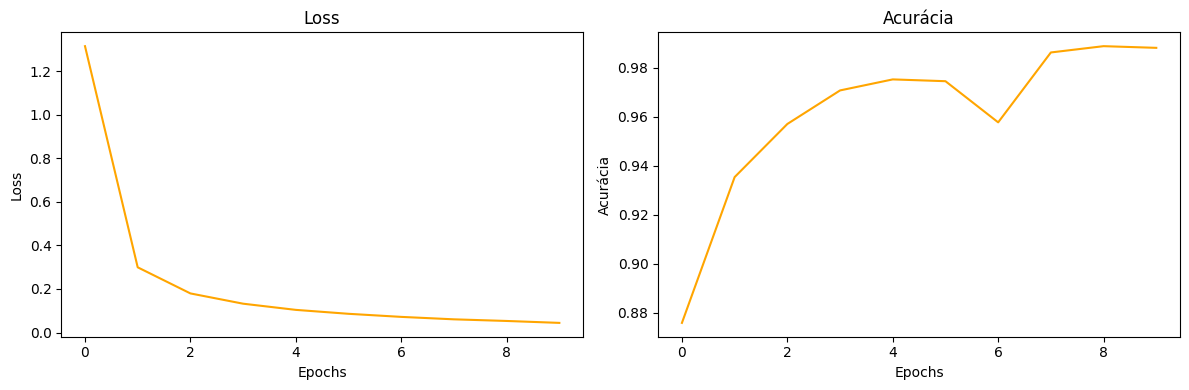

In [12]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(mlp, number=1, color='blue'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(mlp.history_loss, label='Loss', color=color)
    ax1.set_title('Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')

    ax2.plot(mlp.history_acc, label='Acurácia', color=color)
    ax2.set_title('Acurácia')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Acurácia')

    plt.tight_layout()
    plt.savefig(f'../results/loss_accuracy_{number}.png')
    plt.show()


plot_loss_accuracy(mlp_1, number=1, color='blue')
plot_loss_accuracy(mlp_2, number=2, color='orange')